# 022 — Training (unet_v2, unet_restormer + beta-NLL)

Trains three independent things introduced across sessions, in one notebook:

- **Part A — beta-NLL retraining** of the four existing heteroscedastic architectures (`unet_nll`, `resunet_nll`, `attention_unet_nll`, `efficientnet_unet_nll`) with `scripts.losses.beta_gaussian_nll_loss` (Seitzer et al. 2022), which corrects the gradient-starvation issue of the plain Gaussian NLL used in `021_training_nll.ipynb`. Saved to a **separate checkpoint tree** (`models/nll_beta/<arch>/`), not `models/<arch>/`, so the existing `gaussian_nll` checkpoints from `021_training_nll.ipynb` are preserved — `032_evaluation_v2.ipynb` needs both to compare them.
- **Part B — `unet_v2` and `unet_restormer`**, two independent architectural variants of `unet.py`, each trained as its own new architecture name so neither collides with `unet`'s checkpoint (or each other's):
  - `unet_v2` (`scripts/unet_v2.py`) — the standard UNet with three independently-toggleable modifications, all off by default and matching `unet.py` exactly when off: `use_strided_conv` (learned stride-2 convolution instead of `MaxPool2D`), `use_upsample_conv` (bilinear upsample + `Conv2D` instead of `Conv2DTranspose`, avoids checkerboard artifacts), `dropout_rate` (`SpatialDropout2D` at the bottleneck and first decoder block only — see `scripts/unet_v2.py` module docstring for why).
  - `unet_restormer` (`scripts/unet_restormer.py`) — the standard UNet with a Restormer transformer block (Zamir et al. 2022) inserted at the bottleneck, giving the network a global receptive field via channel-wise self-attention (linear cost in image size, not quadratic) — see `code-review.md` §7.3.

Does not modify or retrain `unet`, `resunet`, `attention_unet`, `efficientnet_unet`, or the `gaussian_nll`-trained `*_nll` checkpoints from `021_training_nll.ipynb`.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    grouped_train_val_test_split,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.trainer import compile_model, get_callbacks, get_model
from scripts.trainer_nll import NLL_LOSSES, compile_model_nll, get_model_nll
from scripts.visualization import plot_training_curves

# Seed Python / NumPy / TensorFlow from settings.SEED for reproducible runs.
set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Build datasets

In [ ]:
# Artworks split logic: every artwork ID (including the paint-on-support
# mockup groups) is a group kept entirely within a single fold, to prevent
# leakage between sections of the same painting. This can hold an entire
# mockup group out of training even though those groups exist to aid it.
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = grouped_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    seed=settings.SEED,
)

# crop_size only affects the augmented training split; val stays full-image.
train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

In [3]:
# Mockup-aware split: real artwork groups stay leakage-free (whole group in
# one fold); the 6 mockup groups (settings.MOCKUP_ARTWORK_IDS) are split at
# the individual-pair level instead. Matches the active split in
# 020_training.ipynb / 021_training_nll.ipynb, so both parts below train on
# the same conditions as the checkpoints they will be compared against.
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


2026-08-13 12:48:05.159935: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-13 12:48:05.159955: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-13 12:48:05.159960: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-13 12:48:05.159971: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-13 12:48:05.159980: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Part A — beta-NLL retraining

`LOSS_NAME = "beta_nll"` (`scripts.trainer_nll.NLL_LOSSES`) weights the Gaussian NLL by `stop_gradient(sigma) ** (2 * BETA)`, counteracting the gradient starvation the plain `gaussian_nll` loss shows in high-variance regions. `BETA = 0` would recover `gaussian_nll` exactly — see `code-review.md` §7.6.

Checkpoints go to `BETA_MODEL_DIR = models/nll_beta/<arch>/`, not `models/<arch>/`, so the existing `gaussian_nll` checkpoints are untouched.

In [ ]:
ARCHS_NLL = ["unet_nll", "resunet_nll", "attention_unet_nll", "efficientnet_unet_nll"]
EPOCHS_NLL = settings.EPOCHS  
LOSS_NAME = "beta_nll"
BETA = 0.5

assert LOSS_NAME in NLL_LOSSES, f"LOSS_NAME must be one of {NLL_LOSSES}"

# Separate checkpoint/log tree so this run never overwrites the gaussian_nll
# checkpoints trained in 021_training_nll.ipynb.
BETA_MODEL_DIR = settings.MODELS_DIR / "nll_beta"
BETA_LOG_DIR = settings.LOGS_DIR / "nll_beta"

histories_nll: dict = {}

for arch in ARCHS_NLL:
    print(f"\n{'=' * 60}")
    print(f"  Architecture: {arch}  (loss: {LOSS_NAME}, beta={BETA})")
    print(f"{'=' * 60}")

    model = get_model_nll(arch)
    model = compile_model_nll(
        model, lr=settings.LEARNING_RATE, loss_name=LOSS_NAME, beta=BETA
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(arch, log_dir=BETA_LOG_DIR, model_dir=BETA_MODEL_DIR)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_NLL,
        callbacks=callbacks,
        verbose=1,
    )
    histories_nll[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}, beta_nll): {best_val_loss:.4f}")


  Architecture: unet_nll  (loss: beta_nll, beta=0.5)


Model: "unet_nll"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, None,      │         256 │ conv2d[0][0]       │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, None,      │      36,864 │ re_lu[0][0]        │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, None,      │         256 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, None,      │           0 │ re_lu_1[0][0]      │
│ (MaxPooling2D)        │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, None,      │      73,728 │ max_pooling2d[0][… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, None,      │         512 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, None,      │     147,456 │ re_lu_2[0][0]      │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_3 │ (None, None,      │         512 │ conv2d_3[0][0]     │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_3 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_1       │ (None, None,      │           0 │ re_lu_3[0][0]      │
│ (MaxPooling2D)        │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, None,      │     294,912 │ max_pooling2d_1[0… │
│                       │ None,

 Total params: 31,049,474 (118.44 MB)

 Trainable params: 31,037,698 (118.40 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ multiply_4 (Multiply) │ (None, None,      │           0 │ input_layer_4[0][… │
│                       │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ efficientnet_b0_enco… │ [(None, None,     │   4,049,571 │ multiply_4[0][0]   │
│ (Functional)          │ None, 16), (None, │             │                    │
│                       │ None, None, 24),  │             │                    │
│                       │ (None, None,      │             │                    │
│                       │ None, 40), (None, │             │                    │
│                       │ None, None, 112), │             │                    │
│                       │ (None, None,      │             │                    │
│                       │ None, 1280)]      │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_75 (Conv2D)    │ (None, None,      │   2,949,120 │ efficientnet_b0_e… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │       1,024 │ conv2d_75[0][0]    │
│ (BatchNormalization)  │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_58 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_76 (Conv2D)    │ (None, None,      │     589,824 │ re_lu_58[0][0]     │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │       1,024 │ conv2d_76[0][0]    │
│ (BatchNormalization)  │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_59 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_transpose_12   │ (None, None,      │     131,200 │ re_lu_59[0][0]     │
│ (Conv2DTranspose)     │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ __resize_to_match     │ (None, None,      │           0 │ conv2d_transpose_… │
│ (_ResizeToMatch)      │ None, 128)        │             │ efficientnet_b0_e… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate_12        │ (None, None,      │           0 │ __resize_to_match… │
│ (Concatenate)         │ None, 240)        │             │ efficientnet_b0_e… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_77 (Conv2D)    │ (None, None,      │     276,480 │ concatenate_12[0]… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         512 │ conv2d_77[0][0]    │
│ (BatchNormalization)  │ None,

 Total params: 8,325,573 (31.76 MB)

 Trainable params: 4,273,954 (16.30 MB)

 Non-trainable params: 4,051,619 (15.46 MB)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 0.2225 - mae: 0.2210 - psnr: 12.5590 - ssim: 0.0945
Epoch 1: val_loss improved from None to 0.08635, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll_beta/efficientnet_unet_nll/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll_beta/efficientnet_unet_nll/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - loss: 0.2225 - mae: 0.2210 - psnr: 12.5590 - ssim: 0.0945 - val_loss: 0.0864 - val_mae: 0.2292 - val_psnr: 12.6773 - val_ssim: 0.2263 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: -0.0652 - mae: 0.2097 - psnr: 13.3804 - ssim: 0.2062
Epoch 2: val_loss did not improve from 0.08635
108/108 ━━━━━━━━━━━━━━━━━━━━ 23s 209ms/step - loss: -0.0652 - mae: 0.2097 - psnr: 13.3804 - ssim: 0.2062 - val_loss: 1.5368 - val_mae: 0.2499 - val_psnr: 11.2969 - val_ssim: 0.1247 - learning_rate: 1.0000e-

## 3. Part A — training curves

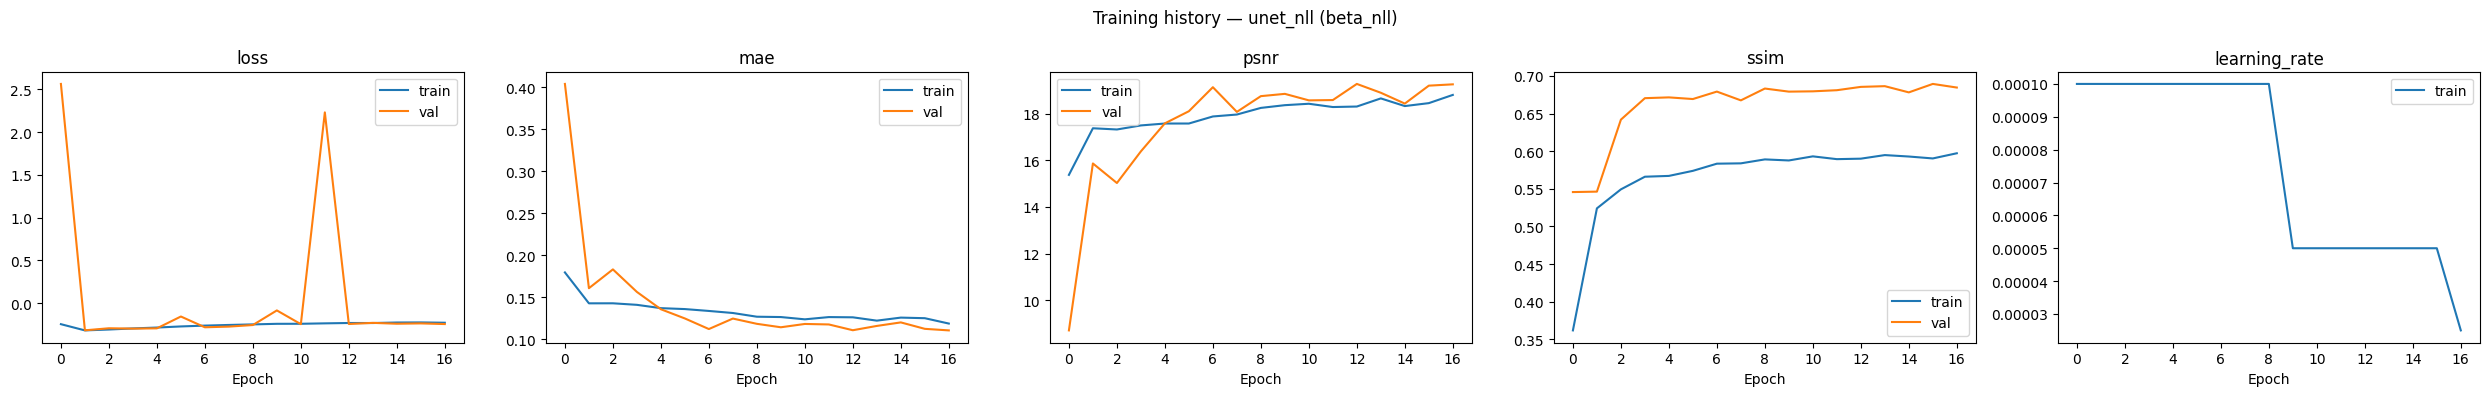

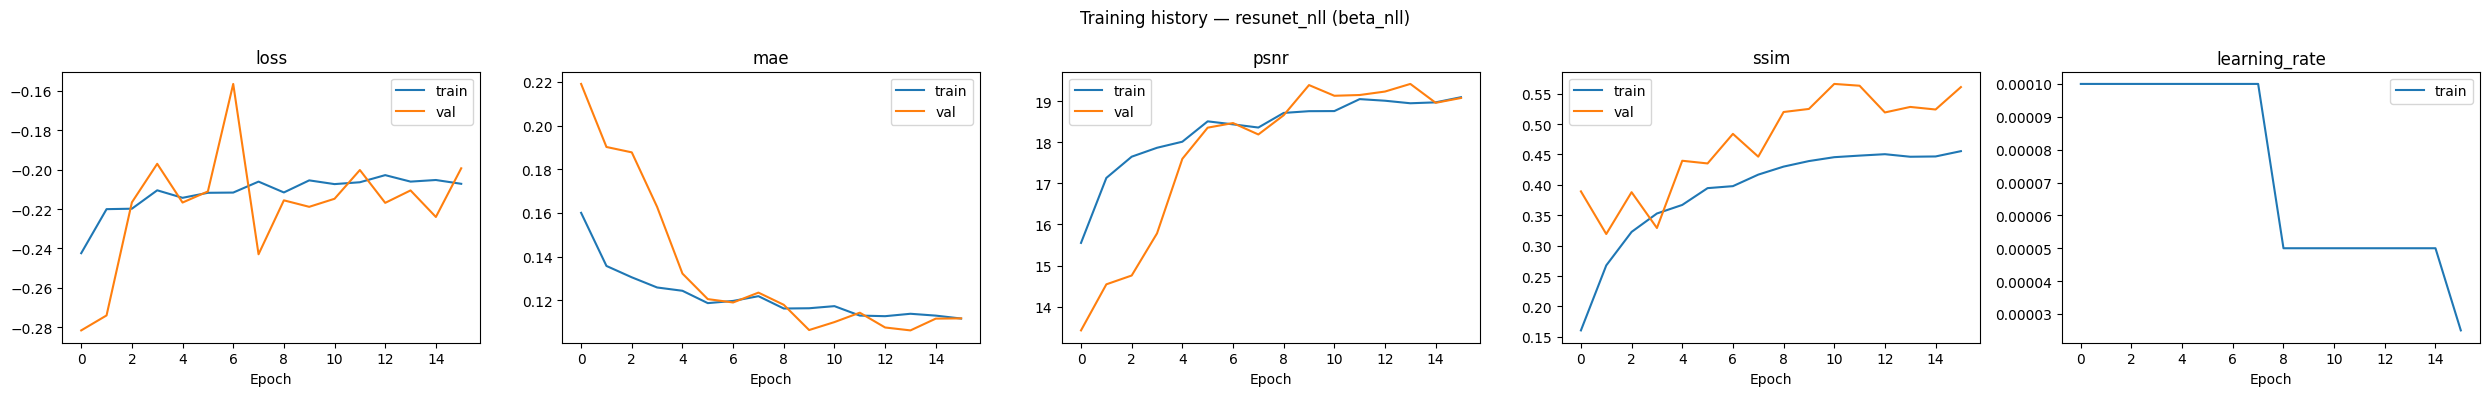

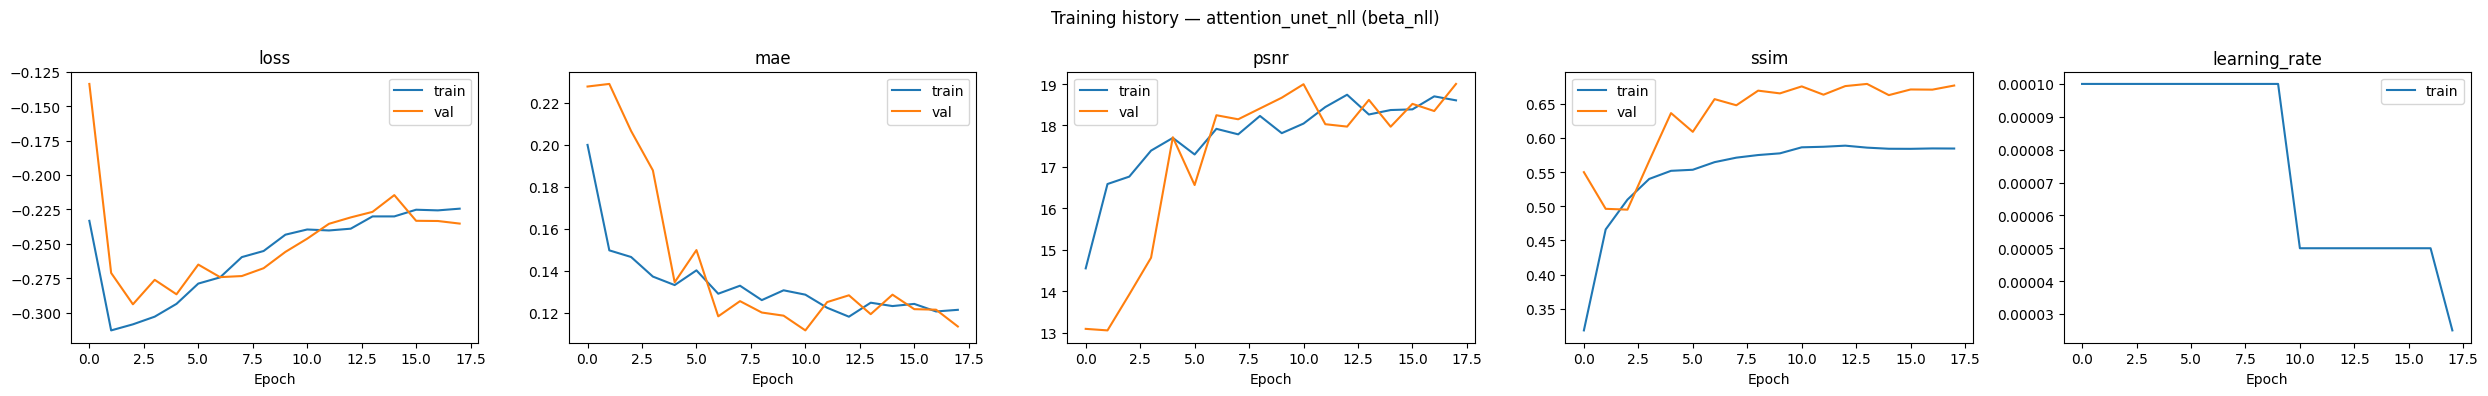

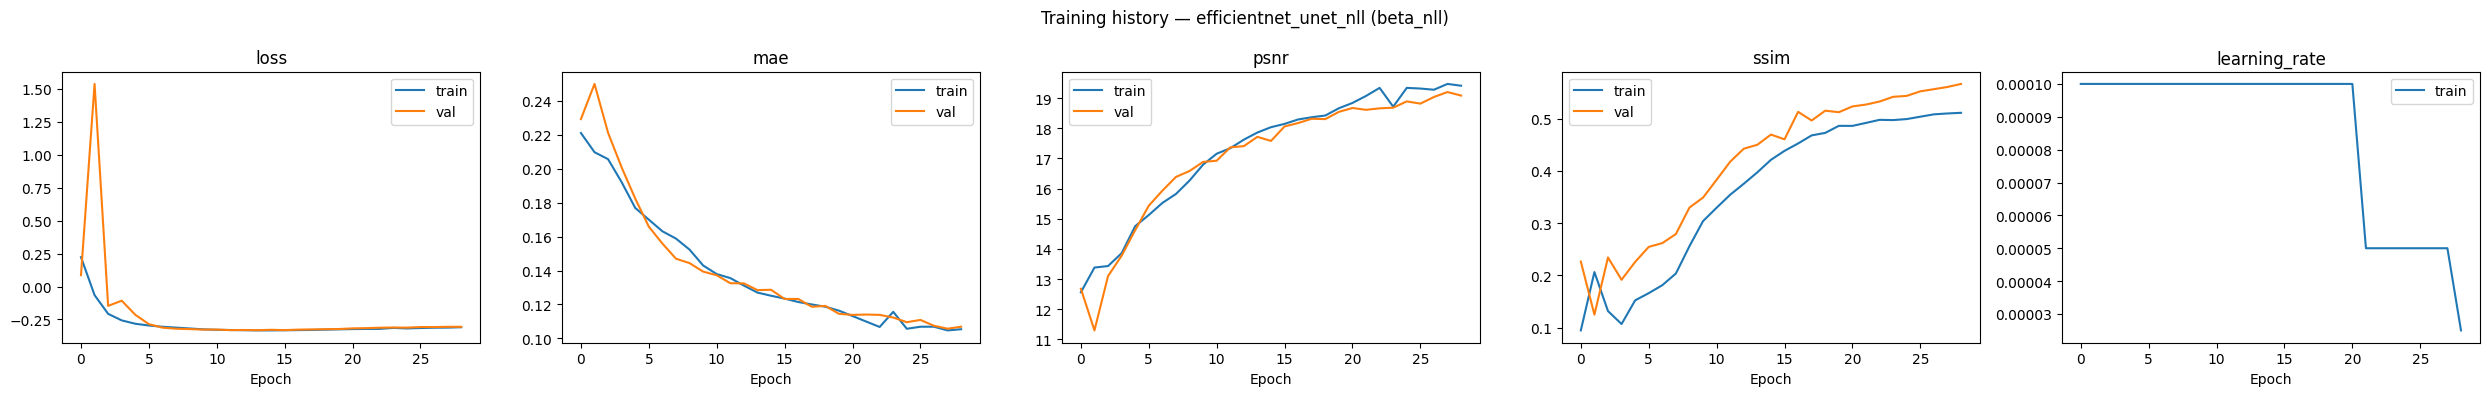

In [5]:
for arch, history in histories_nll.items():
    fig = plot_training_curves(history, title=f"Training history — {arch} (beta_nll)")
    plt.show()

## 4. Part B — unet_v2 and unet_restormer

Set `EPOCHS_DET = 2` for a quick smoke test before committing to a full run. Rerunning this cell overwrites `models/<arch>/best_model.keras` for whichever architecture's config changed — same caveat as `LOSS_NAME` in `021_training_nll.ipynb`.

In [6]:
DET_VARIANTS = {
    "unet_v2": dict(use_strided_conv=True, use_upsample_conv=True, dropout_rate=0.2),
    "unet_restormer": dict(num_heads=8, ffn_expansion_factor=2),
}
EPOCHS_DET = settings.EPOCHS 

histories_det: dict = {}

for arch, kwargs in DET_VARIANTS.items():
    print(f"\n{'=' * 60}")
    print(f"  Architecture: {arch}  ({kwargs})")
    print(f"{'=' * 60}")

    model = get_model(arch, **kwargs)
    model = compile_model(
        model, arch, lr=settings.LEARNING_RATE, loss_alpha=settings.LOSS_ALPHA
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(
        arch, log_dir=settings.LOGS_DIR, model_dir=settings.MODELS_DIR
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_DET,
        callbacks=callbacks,
        verbose=1,
    )
    histories_det[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")


  Architecture: unet_v2  ({'use_strided_conv': True, 'use_upsample_conv': True, 'dropout_rate': 0.2})


Model: "unet_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_87 (Conv2D)    │ (None, None,      │       1,728 │ input_layer_5[0][… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         256 │ conv2d_87[0][0]    │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_70 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_88 (Conv2D)    │ (None, None,      │      36,864 │ re_lu_70[0][0]     │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         256 │ conv2d_88[0][0]    │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_71 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_89 (Conv2D)    │ (None, None,      │      36,864 │ re_lu_71[0][0]     │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         256 │ conv2d_89[0][0]    │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_72 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_90 (Conv2D)    │ (None, None,      │      73,728 │ re_lu_72[0][0]     │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         512 │ conv2d_90[0][0]    │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_73 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_91 (Conv2D)    │ (None, None,      │     147,456 │ re_lu_73[0][0]     │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         512 │ conv2d_91[0][0]    │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_74 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None,

 Total params: 37,671,169 (143.70 MB)

 Trainable params: 37,655,553 (143.64 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_114 (Conv2D)   │ (None, None,      │       1,728 │ input_layer_6[0][… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         256 │ conv2d_114[0][0]   │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_96 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_115 (Conv2D)   │ (None, None,      │      36,864 │ re_lu_96[0][0]     │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         256 │ conv2d_115[0][0]   │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_97 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_12      │ (None, None,      │           0 │ re_lu_97[0][0]     │
│ (MaxPooling2D)        │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_116 (Conv2D)   │ (None, None,      │      73,728 │ max_pooling2d_12[… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         512 │ conv2d_116[0][0]   │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_98 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_117 (Conv2D)   │ (None, None,      │     147,456 │ re_lu_98[0][0]     │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, None,      │         512 │ conv2d_117[0][0]   │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_99 (ReLU)       │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_13      │ (None, None,      │           0 │ re_lu_99[0][0]     │
│ (MaxPooling2D)        │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_118 (Conv2D)   │ (None, None,      │     294,912 │ max_pooling2d_13[… │
│                       │ None,

 Total params: 41,603,785 (158.71 MB)

 Trainable params: 41,592,009 (158.66 MB)

 Non-trainable params: 11,776 (46.00 KB)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - loss: 0.2675 - mae: 0.1525 - psnr: 16.6592 - ssim: 0.4640
Epoch 1: val_loss improved from None to 0.39775, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/unet_restormer/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/unet_restormer/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 112s 965ms/step - loss: 0.2675 - mae: 0.1525 - psnr: 16.6592 - ssim: 0.4640 - val_loss: 0.3977 - val_mae: 0.2300 - val_psnr: 12.7252 - val_ssim: 0.2108 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - loss: 0.2180 - mae: 0.1349 - psnr: 17.8097 - ssim: 0.5880
Epoch 2: val_loss improved from 0.39775 to 0.24421, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/unet_restormer/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/unet_restormer/best_model.keras
108/10

## 5. Part B — training curves

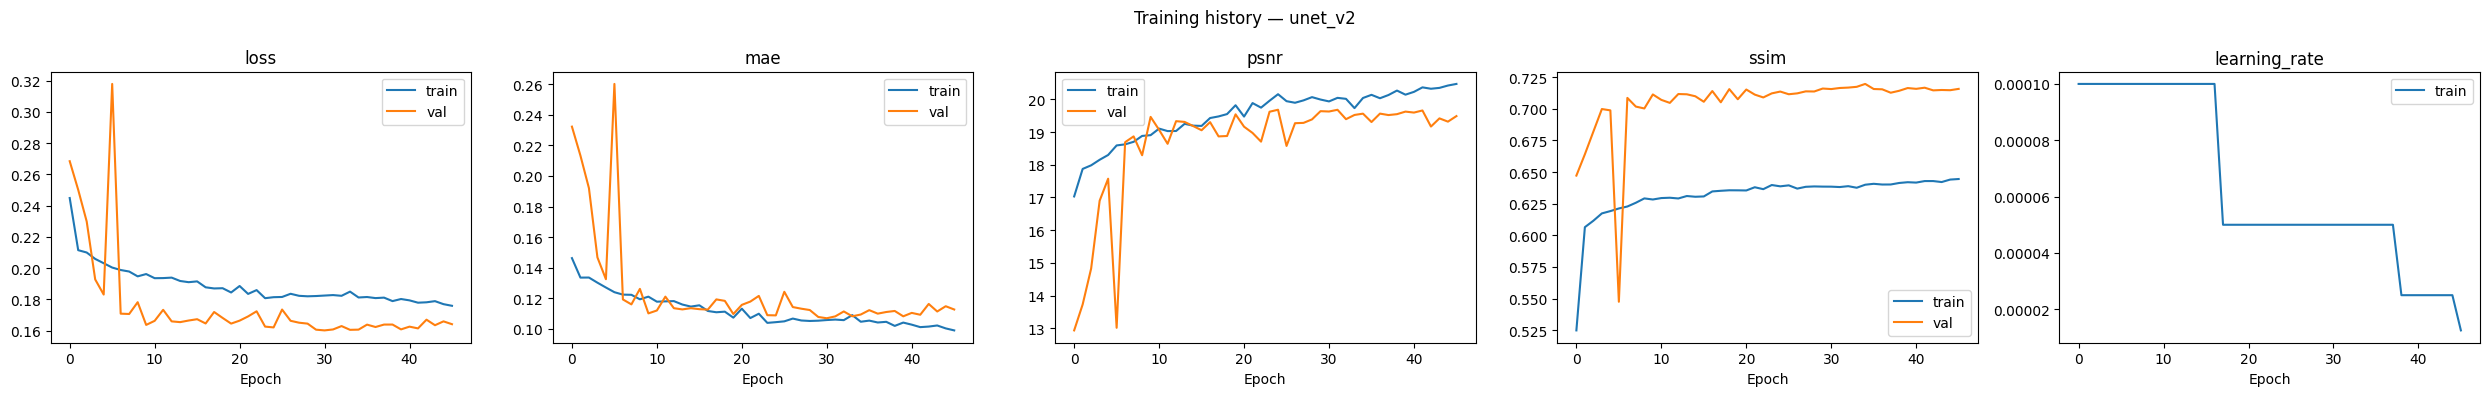

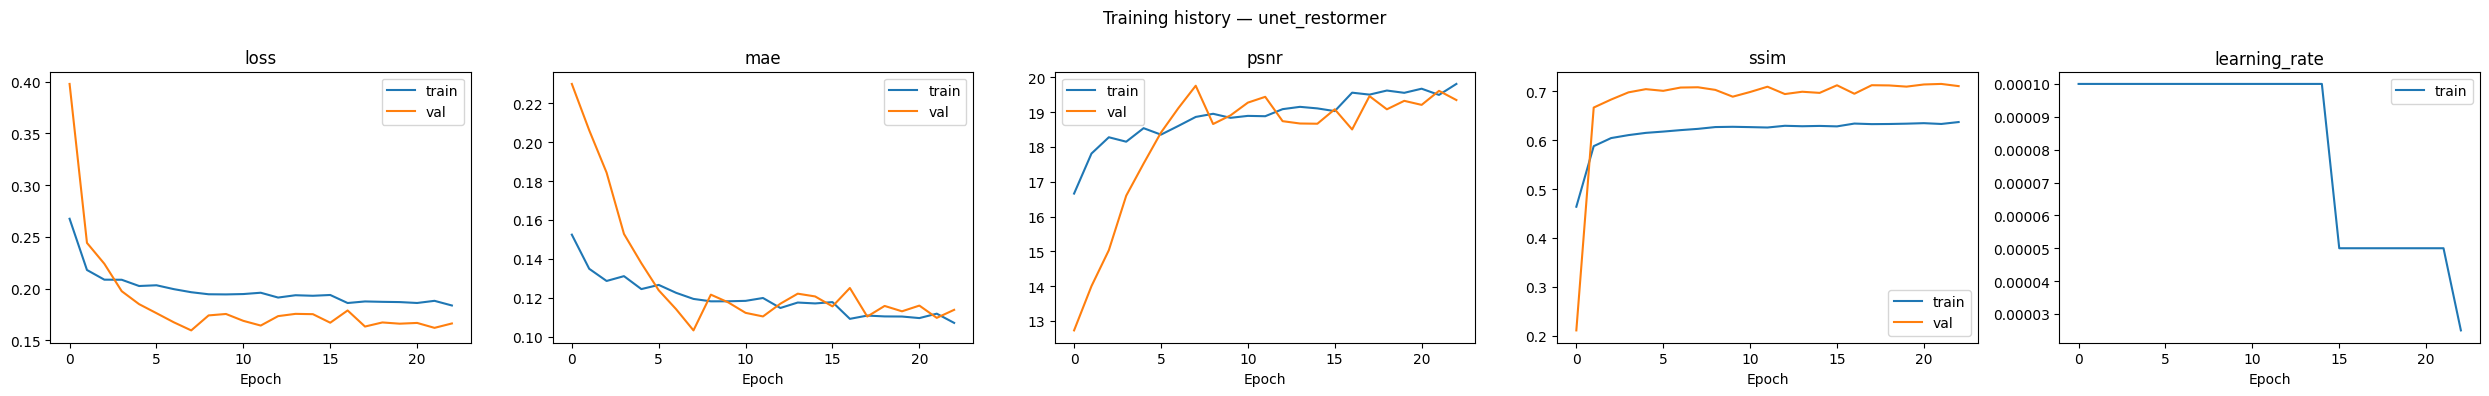

In [7]:
for arch, history in histories_det.items():
    fig = plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

## 6. Summary

Checkpoints saved to:
- `models/nll_beta/<arch>/best_model.keras` for the four beta-NLL architectures (Part A) — the `gaussian_nll` checkpoints at `models/<arch>/best_model.keras` from `021_training_nll.ipynb` are untouched.
- `models/unet_v2/best_model.keras` and `models/unet_restormer/best_model.keras` (Part B).

Run `tensorboard --logdir logs/` to inspect curves interactively.

In [8]:
for arch in ARCHS_NLL:
    ckpt = BETA_MODEL_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25} (beta_nll): {status}  ({ckpt})")

for arch in DET_VARIANTS:
    ckpt = settings.MODELS_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25}          : {status}  ({ckpt})")

unet_nll                  (beta_nll): found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/nll_beta/unet_nll/best_model.keras)
resunet_nll               (beta_nll): found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/nll_beta/resunet_nll/best_model.keras)
attention_unet_nll        (beta_nll): found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/nll_beta/attention_unet_nll/best_model.keras)
efficientnet_unet_nll     (beta_nll): found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/nll_beta/efficientnet_unet_nll/best_model.keras)
unet_v2                            : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/unet_v2/best_model.keras)
unet_restormer                     : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/unet_restormer/best_model.keras)
